In [ ]:
if 'google.colab' in str(get_ipython()):
    ! git clone -b main https://github.com/edsonportosilva/OptiCommPy
    from os import chdir as cd
    cd('/content/OptiCommPy/')
    ! pip install .

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sympy import Matrix, zeros
from numpy.random import normal
import sympy as sp

from optic.models.devices import mzm, iqm, edfa, coherentReceiver
from optic.models.channels import linearFiberChannel, ssfm
from optic.utils import parameters
from optic.dsp.equalization import edc, mimoAdaptEqualizer
from optic.dsp.core import firFilter, pulseShape, lowPassFIR, symbolSync, pnorm, upsample
from optic.comm.metrics import signal_power
from optic.plot import eyediagram, pconst

In [ ]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
import matplotlib as mpl

figsize(17, 3.2)
mpl.rcParams['agg.path.chunksize'] = 10000

## Comunicações Ópticas Coerentes
---

## Sumário
---
- [Por que comunicações ópticas coerentes?](#Por_que_comunicações_ópticas_coerentes?)
- [Receptor coerente](#Receptor_coerente)
- [Ruído de fase](#Ruído_de_fase)

### Por que comunicações ópticas coerentes?
---
Comunicação Óptica Convencional | Comunicação Óptica Coerente
| :--------------: | :--------------: |
Apenas parte real positiva | Amplitude, fase e polarização
Apenas modulações de intensidade (OOK, ASK) | Modulações complexas (BPSK, QPSK, QAM)
Baixa imunidade a ruídos e dispersões | Alta imunidade, mas requer processamento mais complexo
Limitadas, ex: 10 Gbps típicos | 	Altas taxas: 100 Gbps, 400 Gbps ou mais
Equalizadores necessário, simples compensações |  Equalizadores essencial para compensar CD, PMD, ruído de fase
Curta distância | Longa distância

  - Uso de técnicas avançadas de modulação e codificação.
  - Maior eficiência no uso do espectro disponível na fibra.

### Receptor coerente
---

<center><img src = "https://github.com/edsonportosilva/OpticalCommunications/blob/cb0be56856b0b5f30779b4464b12055b600c1a56/jupyter%20notebooks/figuras/hibrida_4x90.png?raw=True" width = "70%"/></center>

  1. A portadora modulada é o sinal óptico transmitido pelo transmissor, já contendo as informações (dados digitais) moduladas em: Amplitude, fase e freqência.
  2. O laser LO (oscillator local) é um laser usado no receptor coerente, cuja função é ajudar a "traduzir" o sinal óptico para um sinal elétrico.
  3. Na híbrida 2 x 4 90°, os sinais são combinados com o laser LO com defasagens controladas. Essas rotação de fase serve para extrair diferentes componentes do sinal pelo BPD (em fase e em quadratura), como se fosse "olhar" o sinal de diferentes ângulos para entender tudo que ele carrega.
  4. A Híbrida 2x4 separa o sinal em dois caminhos:
    - Um deles mistura o sinal com o $LO$ em fase $(0° \ e \ 180°)$, extrai a parte real $s_I(t)$
    - O outro mistura com o LO em quadratura $(90° \ e \ 270°)$ extrai a parte imaginária $s_Q(t)$
  5. $i1, i2, i3, i4$ Saídas dos fotodetectores, usadas para extrair  $s_I(t)$ e $s_Q(t)$

Equações:
$$\begin{equation}
E_s(t) = \sqrt{P_s}A(t)e^{j(ω_ct + φ)} \\
E_{Lo}(t) = \sqrt{P_{Lo}}e^{j(tω_{Lo} + φ_{Lo})} \\
s_Q = i_1(t) - i_2(t) \\
s_I = i_3(t) - i_4(t) \\
s(t) = \sqrt{P_s}\sqrt{P_{Lo}}R_de^{j(ω_ct + φ(t)- tω_{Lo} - φ_{Lo})}
\end{equation}$$

### Ruído de fase
---

O ruído de fase de um laser refere-se às flutuações estocásticas na fase da onda óptica emitida. Essas flutuações resultam em um alargamento da linha espectral do laser, limitando a sua pureza espectral. Em outras palavras, o ruído de fase é responsável pelo alargamento da largura de linha do laser, que é a medida da largura espectral da radiação emitida. A origem física do ruído de fase está associada a processos quânticos e térmicos dentro do laser. Ele surge principalmente de:

  1. **Ruído de Emissão Espontânea:** Durante a amplificação da luz no laser, alguns fótons são emitidos espontaneamente. Cada fóton espontâneo tem uma fase aleatória, que é adicionada à fase da onda de luz principal, "contaminando-a".
  2. **Flutuações no Número de Fótons:** O número de fótons dentro da cavidade do laser não é perfeitamente constante, flutuando devido a processos quânticos. Essas flutuações afetam as propriedades do meio, o que, por sua vez, altera a frequência e a fase da luz.
  3. **Efeitos Térmicos e Mecânicos:** Pequenas variações de temperatura ou vibrações podem alterar as propriedades do meio ativo ou da cavidade ressonante, introduzindo mais instabilidades na fase.

Para um laser ideal com perfil espectral Lorentziano, o espectro de potência é descrito como:
$$\begin{equation}
S(f) = \frac{1}{\pi}\frac{\Delta f/2}{f^2 \ + \ (\Delta f/2)^2} ,
\end{equation}$$
onde:
  - $\Delta f$ é a largura de linha do laser (em Hz),
  - $f$ é o desvio de frequência relativo à frequência central.

A fase acumulada é dada por:
$$\begin{equation}
\phi(t) = \phi(0) + \sqrt{2\pi \Delta f}\int_{0}^{t} \eta(\tau)d\tau,
\end{equation}$$
o que implica que a variância da fase aumenta linearmente com o tempo.


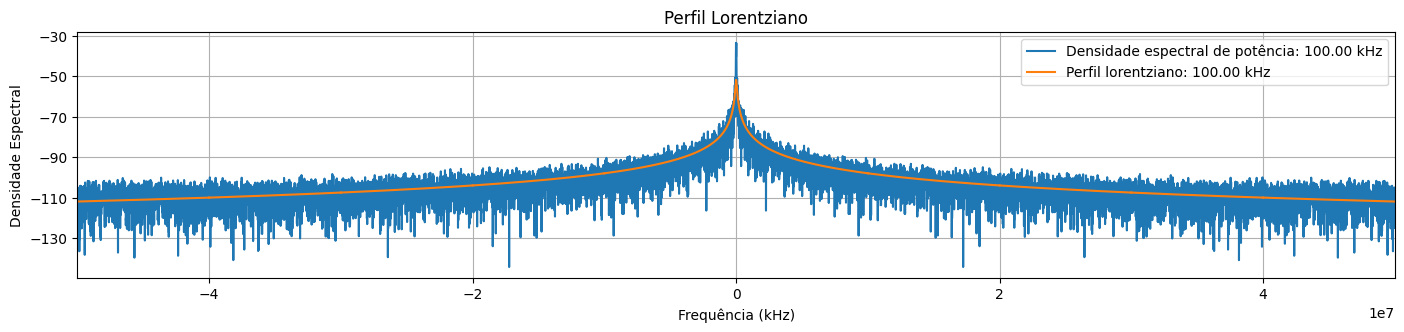

In [ ]:
def phaseNoise(lw, Nsamples, Ts):
    σ2 = 2*np.pi*lw*Ts
    phi = np.zeros(Nsamples)

    for ind in range(0, Nsamples-1):
        phi[ind+1] = phi[ind] + normal(0, np.sqrt(σ2))

    return phi

def lorentzian(f, f0, delta_f):

   return (1 / np.pi) * (delta_f / 2) / ((f - f0)**2 + (delta_f / 2)**2)

# Parâmetros do perfil Lorentziano
f0 = 0      # Frequência central em Hz
lw = 100e3  # Largura de linha em Hz (FWHM)

Fa = 100e6
f = np.linspace(-Fa/2, Fa/2, 100000)  # Intervalo de frequências em Hz

# Cálculo do perfil Lorentziano
S = lorentzian(f, f0, lw)
S = 10*np.log10(S)

# Gera amostras de ruído de fase de acordo com modelo discreto no tempo
Nsamples = 10000
fpsd = np.linspace(-Fa/2, Fa/2, Nsamples)  # Intervalo de frequências em Hz
pn_samples = phaseNoise(lw, Nsamples, 1/Fa)

# Plotar o perfil Lorentziano e PSD calculada
plt.psd(pn_samples, Fs=Fa, NFFT = 16*1024, sides='twosided', label=f'Densidade espectral de potência: {lw/1000:.2f} kHz')
plt.legend(loc='upper left');
plt.plot(f, S, label=f'Perfil lorentziano: {lw/1000:.2f} kHz')
plt.title('Perfil Lorentziano')
plt.xlabel('Frequência (kHz)')
plt.ylabel('Densidade Espectral')
plt.grid(True)
plt.legend()
plt.xlim(-Fa/2, Fa/2)
plt.show()

### Transmissão óptica coerente
----

<center><img src = "https://github.com/edsonportosilva/OpticalCommunications/blob/cb0be56856b0b5f30779b4464b12055b600c1a56/jupyter%20notebooks/figuras/sistemaCoerente.png?raw=True" width = "120%"/></center>
<center>Fonte: GitHub Edson Porto</center>


### Simulação 10G OOK vs 10G BPSK


In [ ]:
modulation = 'BPSK' # 'OOK', 'BPSK'

# parâmetros da simulação
SpS    = 16            # número de amostras por símbolo
Rs     = 10e9          # Taxa de símbolos (para o caso do OOK Rs = Rb)
Ts     = 1/Rs          # Período de símbolo em segundos
Fa     = 1/(Ts/SpS)    # Frequência de amostragem do sinal (amostras/segundo)
Ta     = 1/Fa          # Período de amostragem
π = np.pi

# parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 2

if modulation == 'OOK':
    paramMZM.Vb  = -(paramMZM.Vpi/2)
    Amp = 1
    Pi_dBm = -10+3.5  # potência de sinal óptico na entrada do modulador em dBm
elif modulation == 'BPSK':
    paramMZM.Vb = -(paramMZM.Vpi)
    Amp = 2
    Pi_dBm = -10  # potência de sinal óptico na entrada do modulador em dBm

Pi = 10**(Pi_dBm/10)*1e-3 # potência de sinal óptico em W na entrada do MZM

# parâmetros do receptor
B   = 10e9      # banda do receptor em Hz
Plo_dBm  = 10   # potência do oscilador local
Δf_lo = 0       # desvio de frequência do oscilador local
ϕ_lo  = 0       # fase do oscilador local

Plo = 10**(Plo_dBm/10)*1e-3 # potência do oscilador local na entrada do receptor

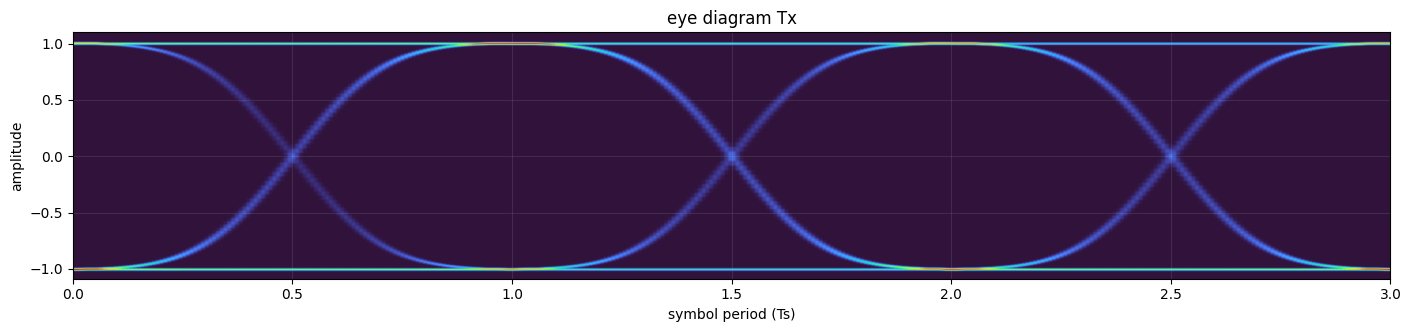

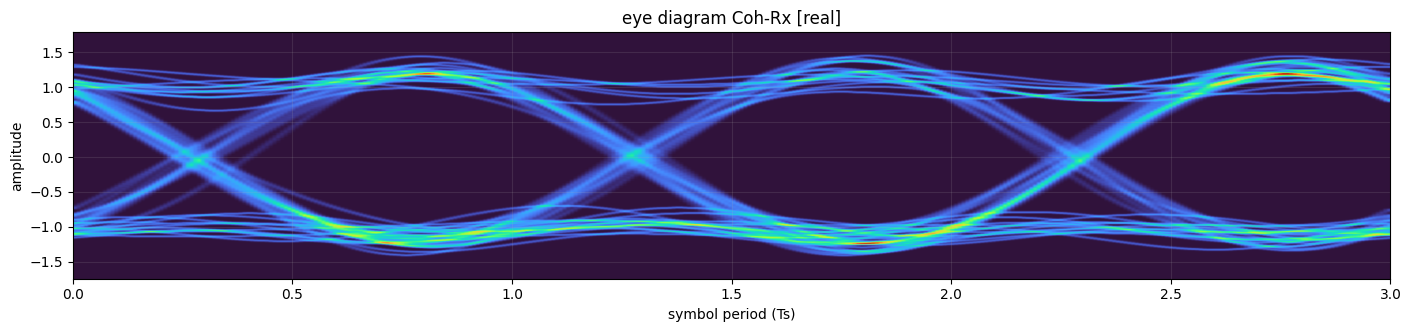

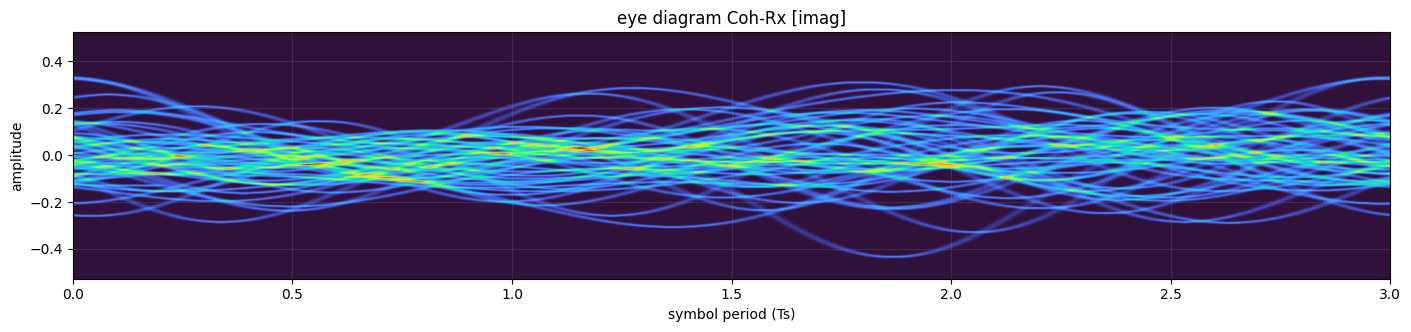

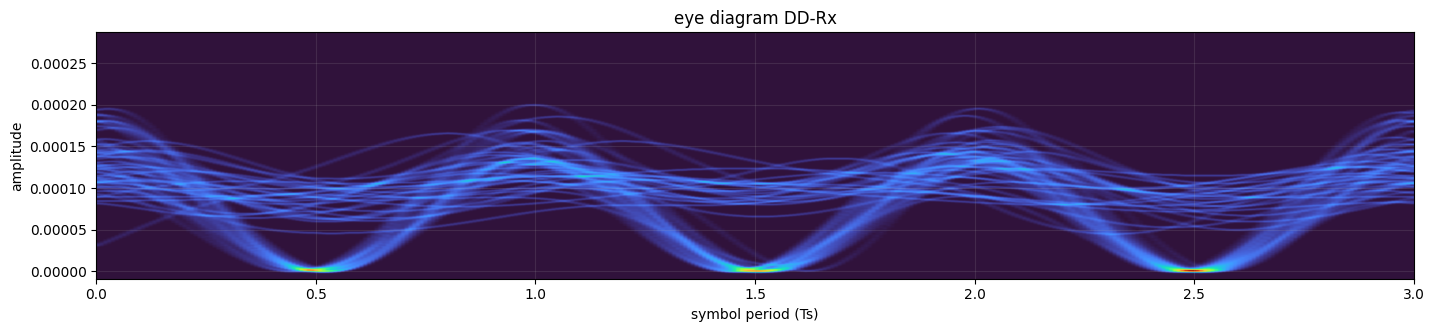

P_sig[opt] = -10.55 dBm
P_ase[opt] = -27.00 dBm
OSNR[est,Bsig] = 16.34 dB 

SNR[est] = 17.42 dB 

Total de erros contados = 0  
BER = 0.00e+00  


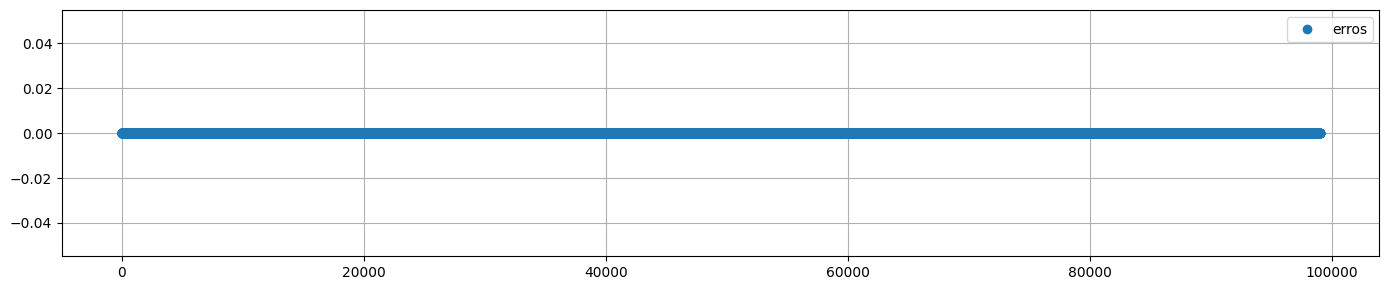

In [ ]:
############# Transmissão óptica coerente #############

### Tx DSP

# gera sequência de bits pseudo-aleatórios
bitsTx = np.random.randint(2, size=100000)
n      = np.arange(0, bitsTx.size)

# mapeia bits para pulsos elétricos
symbTx = 2*bitsTx-1
symbTx = pnorm(symbTx)

# upsampling
symbolsUp = upsample(symbTx, SpS)

# pulso
pulse = pulseShape('nrz', SpS)
pulse = pulse/max(abs(pulse))

# formatação de pulso
sigTx  = firFilter(pulse, symbolsUp)

### modulação óptica
Ai      = np.sqrt(Pi)
sigTxo_ = mzm(Ai, Amp*sigTx, paramMZM)

### Canal Óptico
# adiciona ruído ASE ao sinal óptico
σASE  = 1e-6#1e-5
ruido = normal(0, np.sqrt(Fa*(σASE/(2*B))), sigTxo_.size) + 1j*normal(0, np.sqrt(Fa*(σASE/(2*B))), sigTxo_.size)
sigTxo = sigTxo_ + ruido

### Recepcão coerente
Pin = signal_power(sigTxo) # Potência óptica média recebida

# oscilador local
t     = np.arange(0, sigTxo.size)*Ta
sigLO = np.sqrt(Plo)*np.exp(1j*(2*π*Δf_lo*t + ϕ_lo))

paramPD = parameters()
paramPD.Fs = Fa

# receptor coerente
sigRx = coherentReceiver(sigTxo, sigLO, paramPD)
sigRx = pnorm(sigRx)

### Rx DSP
# filtragem Rx
N = 8001
h = lowPassFIR(B, Fa, N, typeF='rect')
sigRx = firFilter(h, sigRx)

# calculando a OSNR na simulação
sigTxo_Rx   = firFilter(h, sigTxo_)
sigTxo_DDRx = firFilter(h, sigTxo)
ruido_Rx    = firFilter(h, ruido)

OSNR = signal_power(sigTxo_Rx)/signal_power(ruido_Rx)

Nsamples = 10000

sigEye = sigRx.copy()
eyediagram(sigTx,  len(sigTx), SpS, plotlabel = 'Tx', ptype='fancy')
eyediagram(sigEye[int(h.size/SpS)::], len(sigTx), SpS, plotlabel = 'Coh-Rx', ptype='fancy')
eyediagram(np.abs(sigTxo_DDRx)**2,len(sigTxo_DDRx), SpS, plotlabel = 'DD-Rx', ptype='fancy')

# captura amostras no meio dos intervalos de sinalização
sigRx = sigRx[0::SpS]
sigRx = pnorm(sigRx)

if modulation == 'OOK':
    symbTx = (symbTx+1)/np.sqrt(signal_power(symbTx+1))

# Aplica a regra de decisão ótima
bitsRx = np.empty(bitsTx.size)
bitsRx[sigRx> symbTx.mean()] = 1
bitsRx[sigRx<= symbTx.mean()] = 0

discard = 500
ind = np.arange(discard, sigRx.size-discard)

# estima SNR do sinal recebido: SNR = Es/σ^2
SNR = 1/signal_power(sigRx[ind]-symbTx[ind])

err = np.logical_xor(bitsRx[ind],
                     bitsTx[ind])
BER = np.mean(err)

print('P_sig[opt] = %.2f dBm'%(10*np.log10(signal_power(sigTxo_)/1e-3)))
print('P_ase[opt] = %.2f dBm'%(10*np.log10(signal_power(ruido_Rx)/1e-3)))
print('OSNR[est,Bsig] = %.2f dB \n'%(10*np.log10(OSNR)))
print('SNR[est] = %.2f dB \n'%(10*np.log10(SNR)))
print('Total de erros contados = %d  '%(err.sum()))
print('BER = %.2e  '%(BER))

plt.figure()
plt.plot(err,'o', label = 'erros')
plt.legend()
plt.grid()

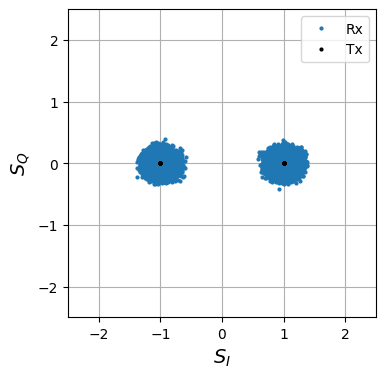

In [ ]:
plt.figure(figsize=(4,4))
plt.axis('square')
plt.ylabel('$S_Q$', fontsize=14)
plt.xlabel('$S_I$', fontsize=14)
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.grid()

plt.plot(sigRx[ind].real,sigRx[ind].imag,'.', markersize=4, label='Rx')
plt.plot(symbTx[ind].real,symbTx[ind].imag,'k.', markersize=4, label='Tx')
plt.legend()

### Simulação com formatos QPSK, QAM

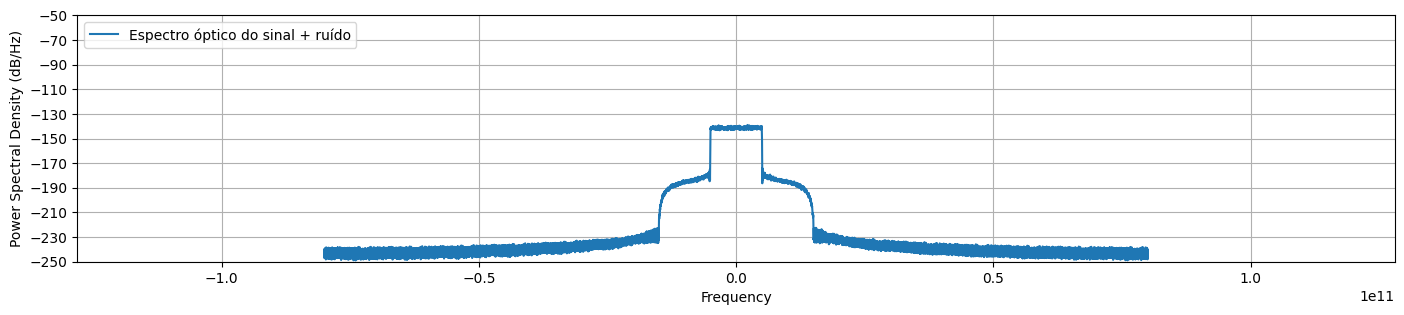

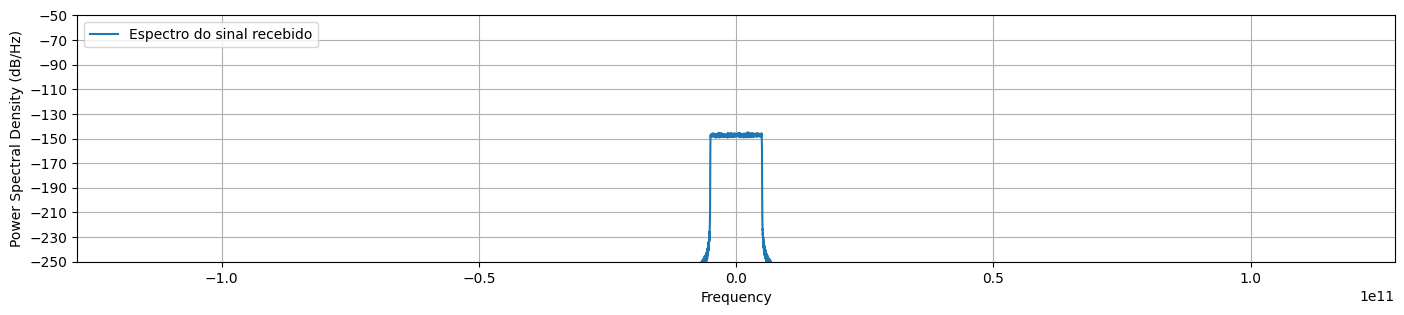

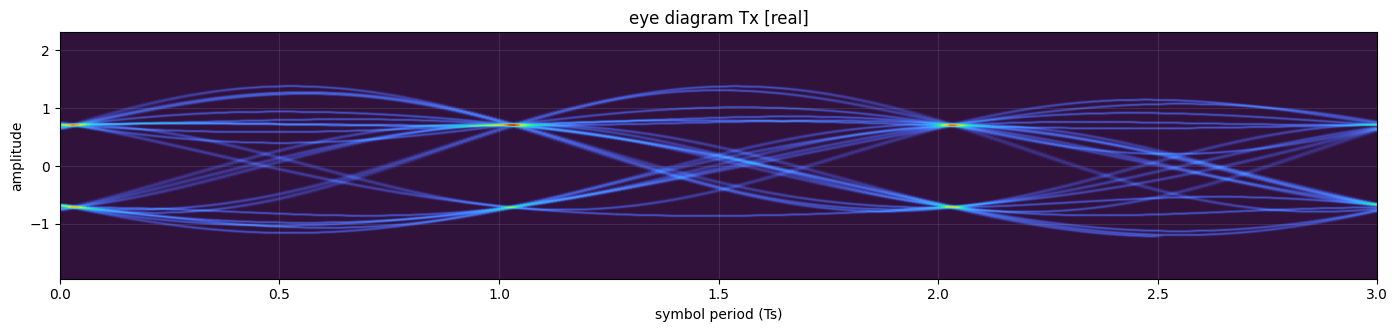

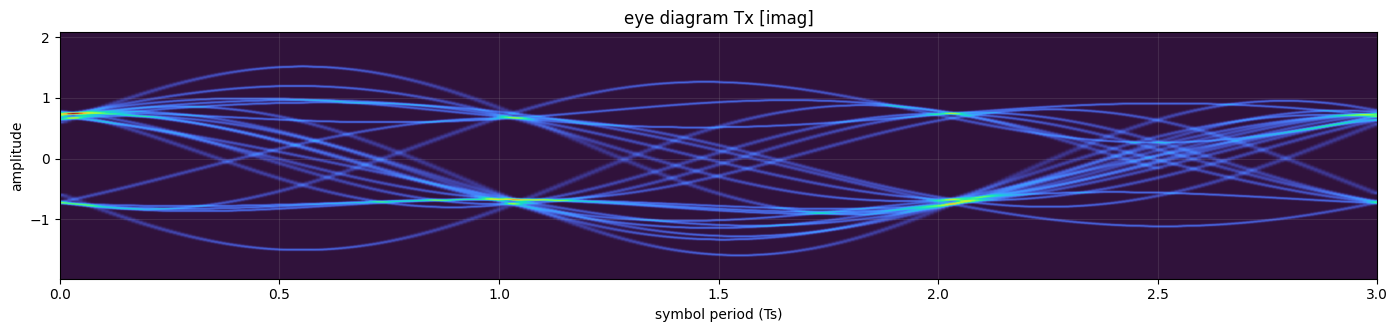

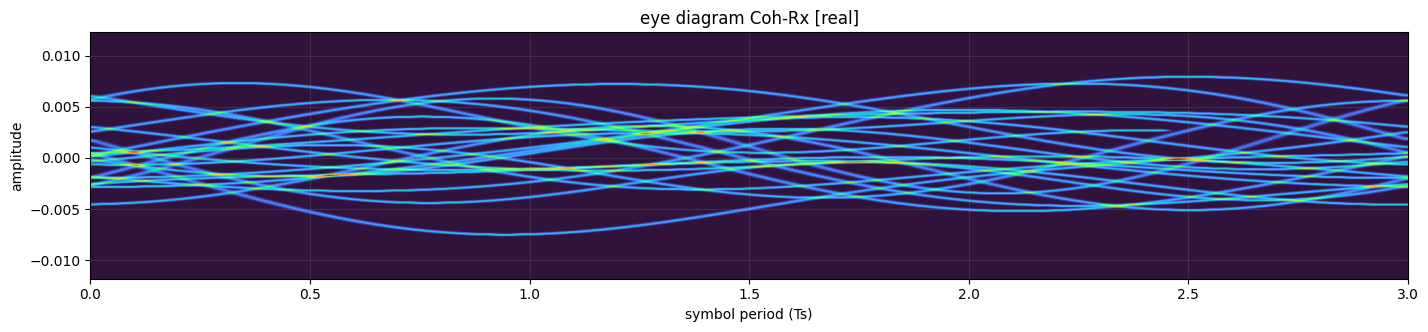

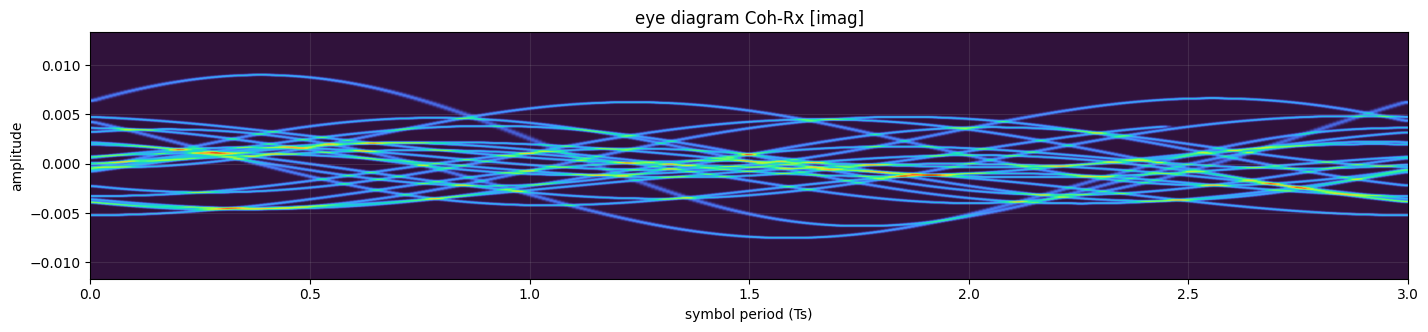

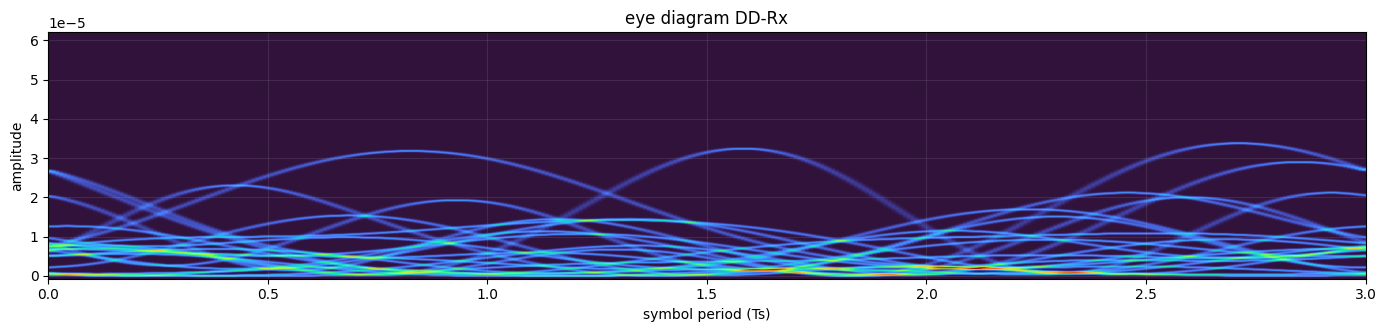

P_sig[opt] = -11.32 dBm
P_ase[opt] = -69.05 dBm
OSNR[est] = -46.38 dB 

SNR[est] = 22.20 dB 

Total de erros contados = 0  
BER = 0.00e+00  


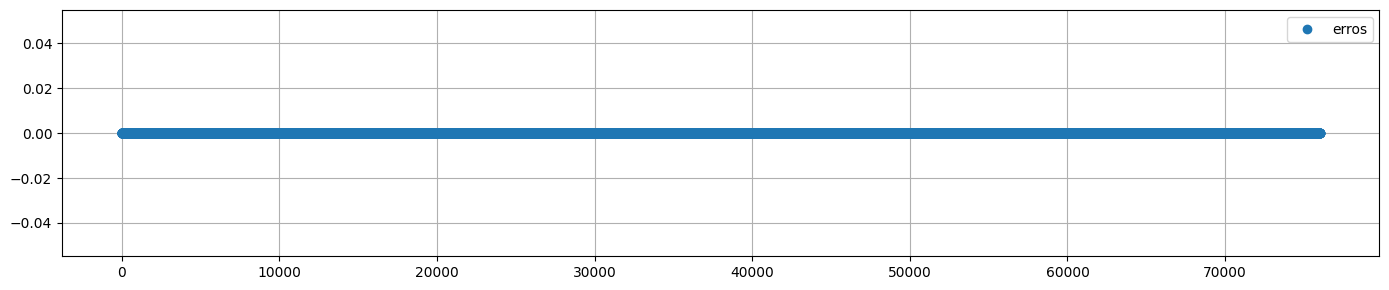

In [ ]:
from optic.comm.modulation import modulateGray, demodulateGray, grayMapping
from optic.dsp.core import pnorm, decimate

plotEyeDiagrams = True
plotPSD         = True

# parâmetros da simulação
M      = 4
SpS    = 16            # número de amostras por símbolo
Rs     = 32e9          # Taxa de símbolos
Ts     = 1/Rs          # Período de símbolo em segundos
Fs     = SpS*Rs        # Frequência de amostragem do sinal (amostras/segundo)

Pi_dBm = 0  # potência de sinal óptico na entrada do modulador em dBm
π = np.pi

# parâmetros do IQM
paramIQM = parameters()
paramIQM.Vpi = 2
paramIQM.Vb = -paramIQM.Vpi

Pi = 10**(Pi_dBm/10)*1e-3 # potência de sinal óptico em W na entrada do MZM

# parâmetros do canal óptico
paramCh = parameters()
paramCh.Ltotal = 20    # km
paramCh.alpha = 0.2    # dB/km
paramCh.D = 16         # ps/nm/km
paramCh.Fc = 193.1e12  # Hz
paramCh.Fs = Fs

# parâmetros do receptor
B  = 32e9     # banda do receptor em Hz

Plo_dBm  = 10     # potência do oscilador local
Δf_lo    = 0      # desvio de frequência do oscilador local
ϕ_lo     = 0      # fase do oscilador local
lw       = 0*10e3 # Largura de linha do laser (em Hz)

Plo = 10**(Plo_dBm/10)*1e-3 # potência do oscilador local na entrada do receptor

############# Simulação #############

### Tx DSP

# gera sequência de bits pseudo-aleatórios
bitsTx   = np.random.randint(2, size=80000)

# mapeia bits para símbolos QAM
symbTx = modulateGray(bitsTx, M, 'qam')

# normaliza energia média dos símbolos para 1
symbTx = pnorm(symbTx)

# upsampling
symbolsUp = upsample(symbTx, SpS)

# pulso
#pulse = pulseShape('nrz', SpS)
pulse = pulseShape('rrc', SpS, N=4096, alpha=0.01, Ts=Ts)
pulse = pulse/np.max(np.abs(pulse))

# formatação de pulso
sigTx  = firFilter(pulse, symbolsUp)

### modulação óptica
Ai      = np.sqrt(Pi)
sigTxo_ = iqm(Ai, 0.5*sigTx, paramIQM)

### Canal Óptico
# adiciona ruído ASE ao sinal óptico
σ2ASE  = 1e-10
σ2 = σ2ASE*(Fa/B)
ruido = normal(0, np.sqrt(σ2), sigTxo_.size) + 1j*normal(0, np.sqrt(σ2), sigTxo_.size)

sigTxo = sigTxo_ + 0*ruido

# calculando a OSNR na simulação
OSNR = signal_power(sigTxo_)/(σ2ASE*B)

# plota psd
if plotPSD:
    plt.figure();
    plt.ylim(-250,-50);
    plt.psd(sigTxo, Fs=Fa, NFFT = 16*1024, sides='twosided', label = 'Espectro óptico do sinal + ruído')
    plt.legend(loc='upper left');
    plt.xlim(-4*Rs,4*Rs);

### Canal óptico linear
sigRxo = linearFiberChannel(sigTxo, paramCh)

### Recepcão coerente
Pin = signal_power(sigTxo) # Potência óptica média média recebida

# oscilador local
t      = np.arange(0, sigRxo.size)*Ta
ϕ_pn_lo  = phaseNoise(lw, sigRxo.size, Ta)

sigLO = np.sqrt(Plo)*np.exp(1j*(2*π*Δf_lo*t + ϕ_lo + ϕ_pn_lo))

paramPD = parameters()
paramPD.Fs = Fa

# receptor coerente
sigRx = coherentReceiver(sigRxo, sigLO, paramPD)

### Rx DSP
# filtragem Rx
sigRx = firFilter(pulse, sigRx)

# plota psd
if plotPSD:
    plt.figure();
    plt.ylim(-250,-50);
    plt.psd(sigRx, Fs=Fa, NFFT = 16*1024, sides='twosided', label = 'Espectro do sinal recebido')
    plt.legend(loc='upper left');
    plt.xlim(-4*Rs,4*Rs);

# calculando a OSNR na simulação
#sigTxo_Rx   = firFilter(h, sigTxo_)
sigRxo_DD = firFilter(h, sigRxo)
ruido_Rx  = firFilter(h, ruido)

Nsamples = 16000
sigEye = sigRx.copy()

#visualiza diagramas de olho
if plotEyeDiagrams:
    eyediagram(sigTx, len(sigTx), SpS, plotlabel = 'Tx', ptype='fancy')
    eyediagram(sigEye[int(h.size/SpS)::], len(sigTx), SpS, plotlabel = 'Coh-Rx',  ptype='fancy')
    eyediagram(np.abs(sigRxo_DD)**2,  len(sigRxo_DD), SpS, plotlabel = 'DD-Rx',  ptype='fancy')

# compensa dispersão cromática
sigRx = edc(sigRx, paramCh)

# captura amostras no meio dos intervalos de sinalização
paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = 1
sigRx = decimate(sigRx.reshape(-1,1), paramDec).reshape(-1,)

discard = 2000
ind = np.arange(discard, sigRx.size-discard)

# normaliza constelação recebida
sigRx = pnorm(sigRx)

# compensa (possível) rotação de fase adicionada pelo canal
rot = np.mean(symbTx[ind]/sigRx[ind])
sigRx  = rot*sigRx

# estima SNR da constelação recebida
SNR = signal_power(symbTx[ind])/signal_power(sigRx[ind]-symbTx[ind])

# Aplica a regra de decisão brusca
constSymb = grayMapping(M, 'qam')
Es = np.mean(np.abs(constSymb) ** 2)
bitsRx = demodulateGray(np.sqrt(Es)*pnorm(sigRx), M, 'qam')

err = np.logical_xor(bitsRx[discard:bitsRx.size-discard],
                     bitsTx[discard:bitsTx.size-discard])
BER = np.mean(err)

print('P_sig[opt] = %.2f dBm'%(10*np.log10(signal_power(sigTxo_)/1e-3)))
print('P_ase[opt] = %.2f dBm'%(10*np.log10(signal_power(ruido_Rx)/1e-3)))
print('OSNR[est] = %.2f dB \n'%(10*np.log10(OSNR)))
print('SNR[est] = %.2f dB \n'%(10*np.log10(SNR)))
print('Total de erros contados = %d  '%(err.sum()))
print('BER = %.2e  '%(BER))

plt.figure()
plt.plot(err,'o', label = 'erros')
plt.legend()
plt.grid()

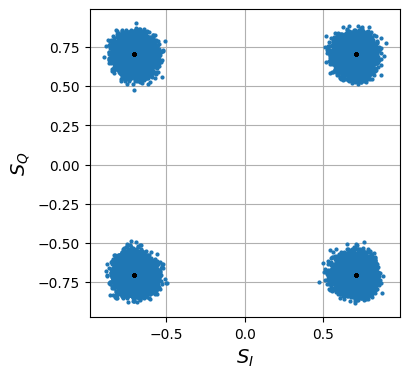

In [ ]:
plt.figure(figsize=(4,4))
plt.ylabel('$S_Q$', fontsize=14)
plt.xlabel('$S_I$', fontsize=14)
#plt.xlim(-1.1,1.1)
#plt.ylim(-1.1,1.1)
plt.grid()

plt.plot(sigRx[ind].real,sigRx[ind].imag,'.', markersize=4, label='Rx')
plt.plot(symbTx[ind].real,symbTx[ind].imag,'k.', markersize=4, label='Tx');